Loading model...
Model loaded successfully
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetb2 (Functional  (None, 8, 8, 1408)        7768569   
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1408)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_1 (Bat  (None, 1408)              5632      
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 1408)              0         
                

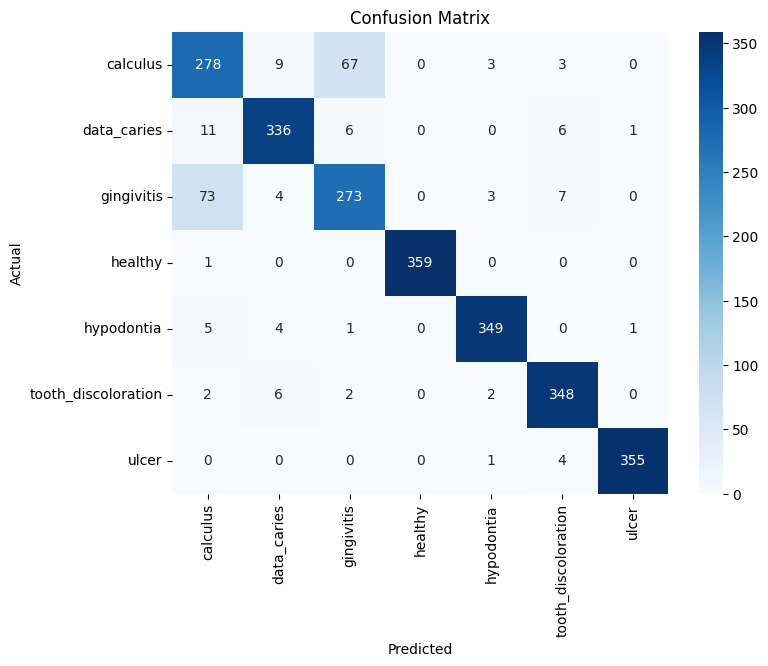


PER CLASS ACCURACY
calculus: 0.7722
data_caries: 0.9333
gingivitis: 0.7583
healthy: 0.9972
hypodontia: 0.9694
tooth_discoloration: 0.9667
ulcer: 0.9861

ROC-AUC Score: 0.9916736478542035

Prediction Confidence Stats
Average confidence: 0.88117915
Min confidence: 0.28710538
Max confidence: 1.0

DEPLOYMENT CHECK
Model performance is GOOD for deployment.


In [1]:
# IMPORT LIBRARIES

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# 2️⃣ PATHS

MODEL_PATH = r"E:\Final Project\Main Folder\Notebooks\Models\oral7_finetuned.h5"
TEST_DIR = r"E:\Final Project\Main Folder\oral\oral_disease_classification\test"

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

# LOAD MODEL

print("Loading model...")
model = load_model(MODEL_PATH)

print("Model loaded successfully")
print(model.summary())

# LOAD TEST DATASET


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names
NUM_CLASSES = len(class_names)

print("\nClasses:", class_names)


# APPLY SAME PREPROCESSING AS TRAINING
AUTOTUNE = tf.data.AUTOTUNE

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.prefetch(AUTOTUNE)

# RUN PREDICTIONS

print("\nRunning predictions...")

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    
    preds = model.predict(images, verbose=0)

    y_prob.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())


y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


# BASIC METRICS

accuracy = np.mean(y_true == y_pred)

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# CLASSIFICATION REPORT

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(classification_report(y_true, y_pred, target_names=class_names))

# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# PER CLASS ACCURACY

print("\n==============================")
print("PER CLASS ACCURACY")
print("==============================")

for i, class_name in enumerate(class_names):
    
    idx = y_true == i
    acc = np.mean(y_pred[idx] == i)

    print(f"{class_name}: {acc:.4f}")


# ROC-AUC SCORE (MULTI CLASS)


try:
    roc_auc = roc_auc_score(
        tf.keras.utils.to_categorical(y_true, NUM_CLASSES),
        y_prob,
        multi_class="ovr"
    )

    print("\nROC-AUC Score:", roc_auc)

except:
    print("\nROC-AUC could not be calculated.")

# PREDICTION CONFIDENCE CHECK

max_probs = np.max(y_prob, axis=1)

print("\nPrediction Confidence Stats")

print("Average confidence:", np.mean(max_probs))
print("Min confidence:", np.min(max_probs))
print("Max confidence:", np.max(max_probs))


# FINAL DEPLOYMENT CHECK

print("\n==============================")
print("DEPLOYMENT CHECK")
print("==============================")

if accuracy > 0.85:
    print("Model performance is GOOD for deployment.")
else:
    print("Model performance may need improvement.")

In [2]:
# print(model.input_shape)

(None, 256, 256, 3)


In [5]:
# Configuration 

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (256,256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


In [7]:
# Universal Evaluation Function

def evaluate_medical_model(model_path, test_dir):

    print("\nLoading model...")
    model = load_model(model_path)

    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = test_ds.class_names
    num_classes = len(class_names)

    print("Classes:", class_names)

    test_ds = test_ds.map(lambda x,y:(preprocess_input(x),y),
                          num_parallel_calls=AUTOTUNE)

    test_ds = test_ds.prefetch(AUTOTUNE)

    y_true=[]
    y_pred=[]
    y_prob=[]
    images_store=[]

    print("\nRunning predictions...")

    for images,labels in test_ds:

        preds = model.predict(images,verbose=0)

        y_prob.extend(preds)
        y_pred.extend(np.argmax(preds,axis=1))
        y_true.extend(labels.numpy())

        images_store.extend(images.numpy())

    y_true=np.array(y_true)
    y_pred=np.array(y_pred)
    y_prob=np.array(y_prob)

    print("Prediction completed")

    return y_true,y_pred,y_prob,np.array(images_store),class_names

In [9]:
# ROC Curve for Each Disease
# Shows how well the model separates each disease class.

def plot_multiclass_roc(y_true,y_prob,class_names):

    n_classes=len(class_names)

    y_true_bin=tf.keras.utils.to_categorical(y_true,n_classes)

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        fpr,tpr,_=roc_curve(y_true_bin[:,i],y_prob[:,i])
        roc_auc=auc(fpr,tpr)

        plt.plot(fpr,tpr,label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve per Disease")
    plt.legend()
    plt.show()

In [11]:
# Precision-Recall Curves

def plot_precision_recall(y_true,y_prob,class_names):

    n_classes=len(class_names)
    y_true_bin=tf.keras.utils.to_categorical(y_true,n_classes)

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        precision,recall,_=precision_recall_curve(
            y_true_bin[:,i],y_prob[:,i]
        )

        ap=average_precision_score(y_true_bin[:,i],y_prob[:,i])

        plt.plot(recall,precision,
                 label=f"{class_names[i]} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()


In [12]:
# Misclassified Image Visualization

def show_misclassified(images,y_true,y_pred,class_names,max_images=12):

    mis_idx=np.where(y_true!=y_pred)[0]

    print("Total Misclassified:",len(mis_idx))

    plt.figure(figsize=(12,10))

    for i,idx in enumerate(mis_idx[:max_images]):

        plt.subplot(3,4,i+1)

        img=images[idx]

        img=(img-img.min())/(img.max()-img.min())

        plt.imshow(img)

        true_label=class_names[y_true[idx]]
        pred_label=class_names[y_pred[idx]]

        plt.title(f"T:{true_label}\nP:{pred_label}",fontsize=9)
        plt.axis("off")

    plt.suptitle("Misclassified Samples")
    plt.show()

In [13]:
# Model Reliability Analysis 

def reliability_analysis(y_pred,y_prob):

    confidence=np.max(y_prob,axis=1)

    correct=(y_pred==np.argmax(y_prob,axis=1))

    plt.hist(confidence,bins=20)
    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.show()

    print("\nConfidence statistics")

    print("Average confidence:",np.mean(confidence))
    print("Minimum confidence:",np.min(confidence))
    print("Maximum confidence:",np.max(confidence))


Loading model...
Found 2520 files belonging to 7 classes.
Classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']

Running predictions...
Prediction completed


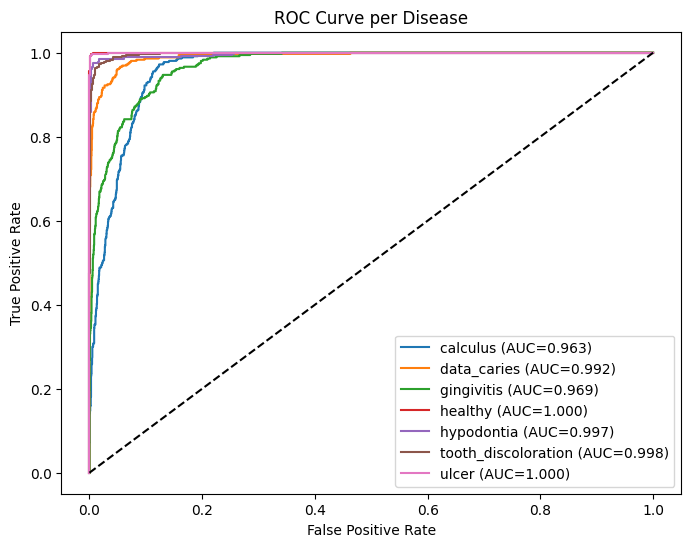

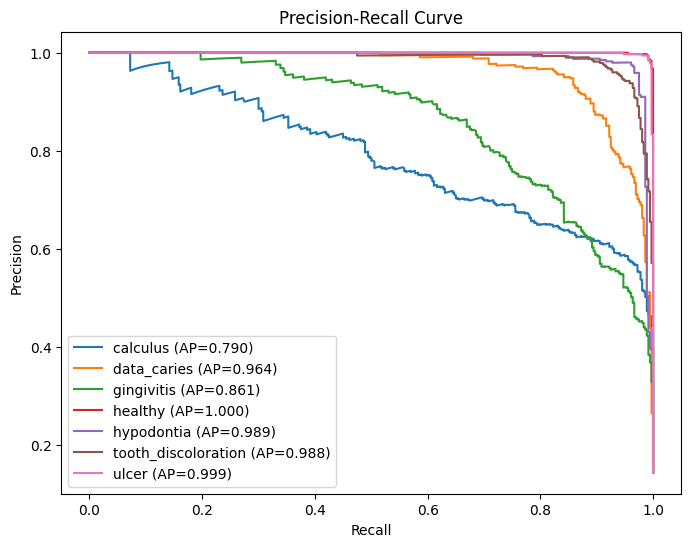

Total Misclassified: 300


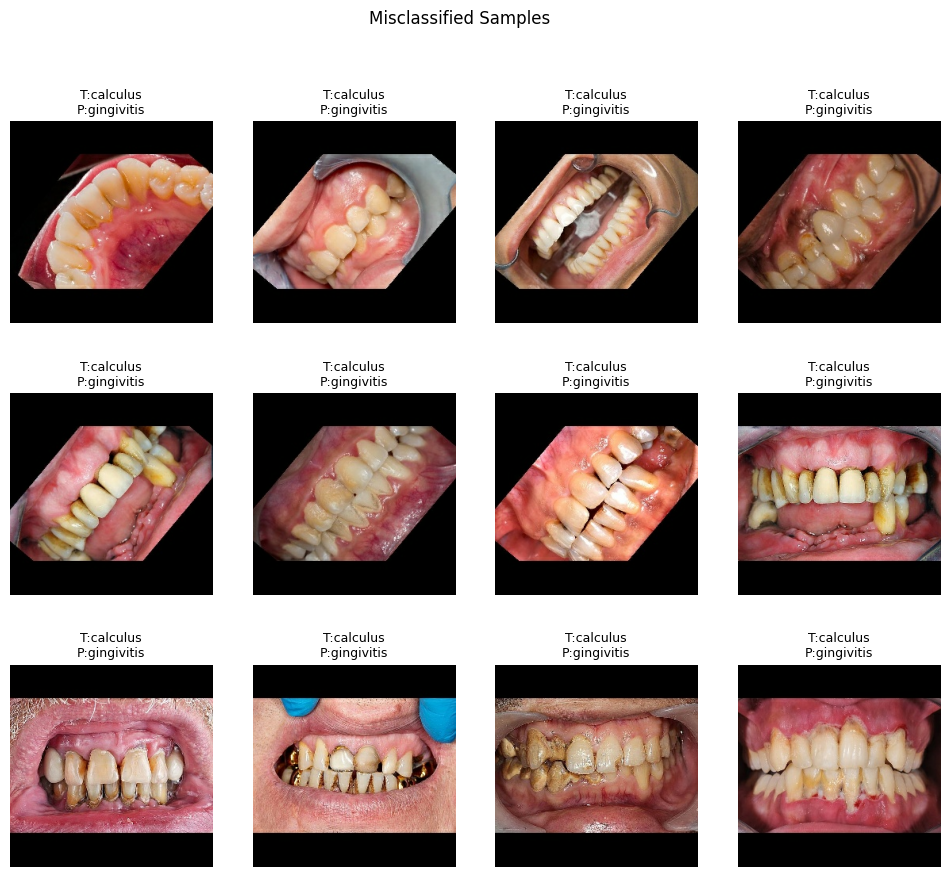

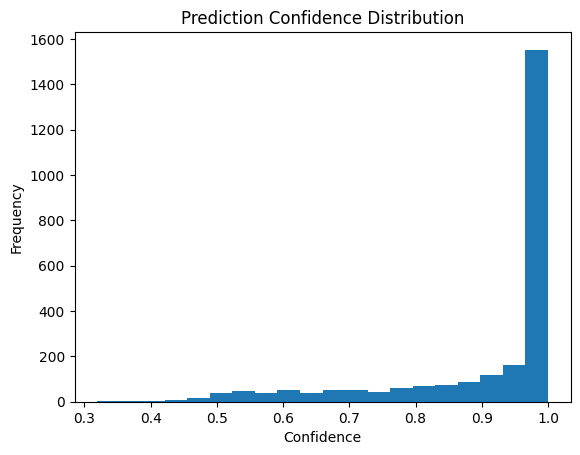


Confidence statistics
Average confidence: 0.9098235
Minimum confidence: 0.3191145
Maximum confidence: 1.0


In [15]:
# Run for ORAL MODEL
oral_model = r"E:\Final Project\Main Folder\Notebooks\Models\oral7_finetuned.h5"

oral_test = r"E:\Final Project\Main Folder\oral\oral_disease_classification\test"

y_true,y_pred,y_prob,images,class_names = evaluate_medical_model(
    oral_model,
    oral_test
)

plot_multiclass_roc(y_true,y_prob,class_names)

plot_precision_recall(y_true,y_prob,class_names)

show_misclassified(images,y_true,y_pred,class_names)

reliability_analysis(y_pred,y_prob)

#### All in one cell

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# DATASET LOADER

def load_dataset(dataset_path, img_size):

    ds = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
        image_size=img_size,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = ds.class_names

    ds = ds.map(
        lambda x,y:(preprocess_input(x),y),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.prefetch(AUTOTUNE)

    return ds, class_names

# RUN PREDICTIONS

def run_predictions(model, ds):

    y_true=[]
    y_pred=[]
    y_prob=[]
    images_store=[]

    for images,labels in ds:

        preds=model.predict(images,verbose=0)

        y_prob.extend(preds)
        y_pred.extend(np.argmax(preds,axis=1))
        y_true.extend(labels.numpy())
        images_store.extend(images.numpy())

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob),
        np.array(images_store)
    )

# ROC CURVE

def plot_roc(y_true,y_prob,class_names):

    n_classes=len(class_names)
    y_true_bin=tf.keras.utils.to_categorical(y_true,n_classes)

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        fpr,tpr,_=roc_curve(y_true_bin[:,i],y_prob[:,i])
        roc_auc=auc(fpr,tpr)

        plt.plot(fpr,tpr,label=f"{class_names[i]} AUC={roc_auc:.3f}")

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve per Disease")

    plt.legend()

    plt.show()

# PRECISION RECALL

def plot_pr(y_true,y_prob,class_names):

    n_classes=len(class_names)
    y_true_bin=tf.keras.utils.to_categorical(y_true,n_classes)

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        precision,recall,_=precision_recall_curve(
            y_true_bin[:,i],
            y_prob[:,i]
        )

        ap=average_precision_score(
            y_true_bin[:,i],
            y_prob[:,i]
        )

        plt.plot(recall,precision,label=f"{class_names[i]} AP={ap:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.title("Precision-Recall Curve")

    plt.legend()

    plt.show()

# MISCLASSIFIED IMAGES

def show_misclassified(images,y_true,y_pred,class_names):

    mis=np.where(y_true!=y_pred)[0]

    print("Total misclassified:",len(mis))

    plt.figure(figsize=(12,10))

    for i,idx in enumerate(mis[:12]):

        plt.subplot(3,4,i+1)

        img=images[idx]
        img=(img-img.min())/(img.max()-img.min())

        plt.imshow(img)

        plt.title(
            f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}",
            fontsize=9
        )

        plt.axis("off")

    plt.show()


# RELIABILITY ANALYSIS

def reliability_analysis(y_prob):

    confidence=np.max(y_prob,axis=1)

    plt.hist(confidence,bins=20)

    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")

    plt.show()

    print("Average confidence:",np.mean(confidence))
    print("Minimum confidence:",np.min(confidence))
    print("Maximum confidence:",np.max(confidence))

# CONFUSION MATRIX

def error_analysis(y_true,y_pred,class_names):

    cm=confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.show()

# Calibration Curve

from sklearn.calibration import calibration_curve

def plot_calibration(y_true, y_prob):

    # confidence of prediction
    confidence = np.max(y_prob, axis=1)

    # predicted class
    predictions = np.argmax(y_prob, axis=1)

    # correct or incorrect prediction
    correct = (predictions == y_true)

    # calibration calculation
    prob_true, prob_pred = calibration_curve(
        correct,
        confidence,
        n_bins=10
    )

    plt.figure(figsize=(6,5))

    plt.plot(prob_pred, prob_true, marker='o', label="Model")

    plt.plot([0,1],[0,1],'--', label="Perfect calibration")

    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")

    plt.title("Model Calibration Curve")

    plt.legend()

    plt.show()

Found 2520 files belonging to 7 classes.
Total misclassified: 300


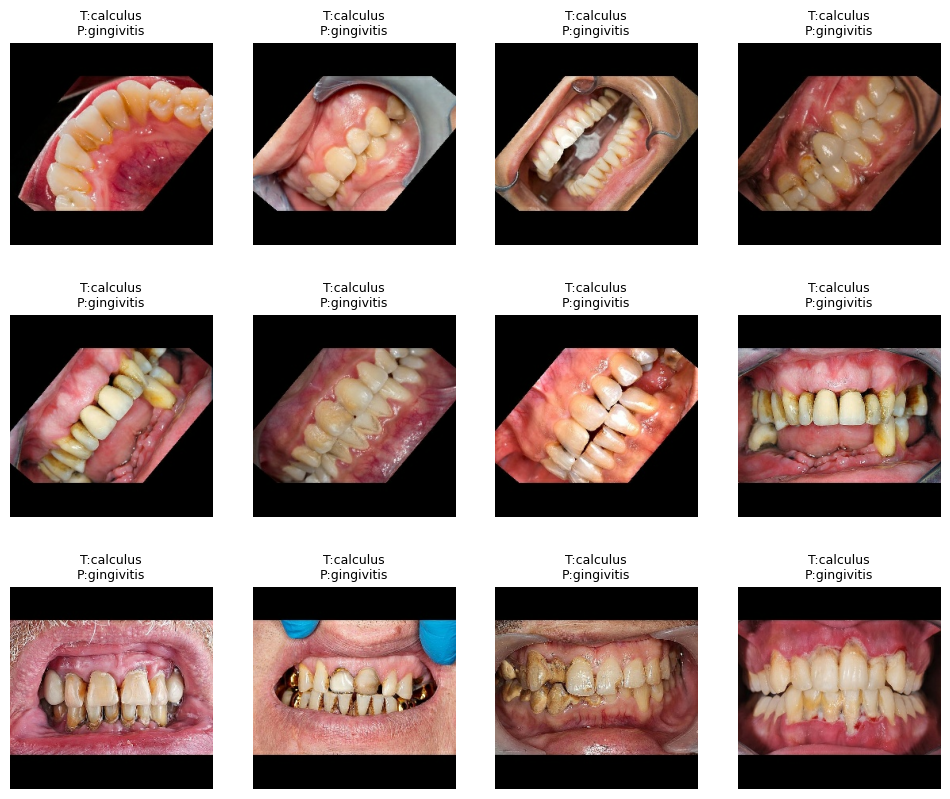

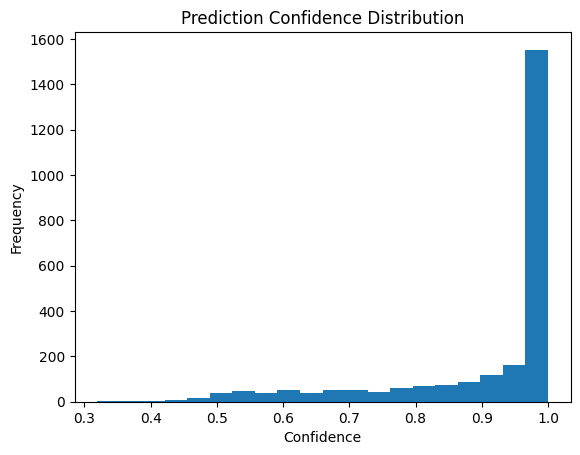

Average confidence: 0.9098235
Minimum confidence: 0.3191145
Maximum confidence: 1.0


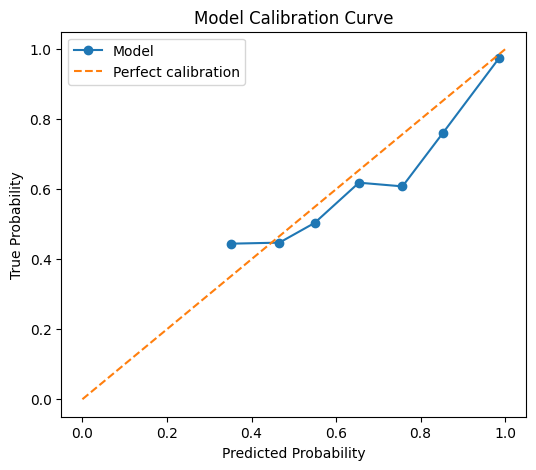

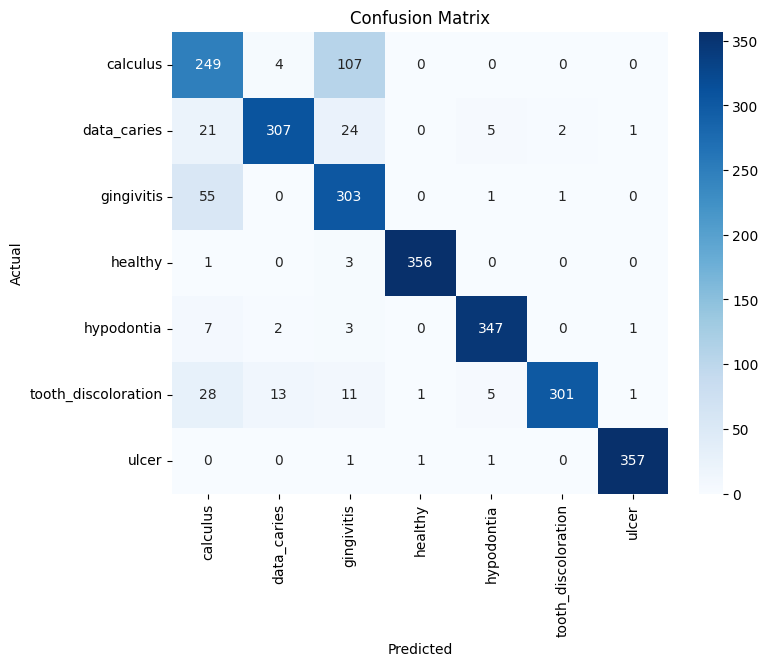

In [19]:
# ORAL MODEL COMPLETE ANALYSIS

oral_model = load_model(
r"E:\Final Project\Main Folder\Notebooks\oral7_best_model.keras"
)

oral_dataset = r"E:\Final Project\Main Folder\oral\oral_disease_classification\test"

ds_oral, oral_classes = load_dataset(
oral_dataset,
(256,256)
)

y_true_o, y_pred_o, y_prob_o, images_o = run_predictions(
oral_model,
ds_oral
)

# MISCLASSIFIED IMAGES

show_misclassified(
images_o,
y_true_o,
y_pred_o,
oral_classes
)

# RELIABILITY ANALYSIS

reliability_analysis(
y_prob_o
)

# CALIBRATION CURVE

plot_calibration(
y_true_o,
y_prob_o
)

# ERROR ANALYSIS

error_analysis(
y_true_o,
y_pred_o,
oral_classes
)


In [21]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve

def model_evaluation_dashboard(y_true, y_pred, y_prob, class_names, model_name="Model"):

    n_classes = len(class_names)

    y_true_bin = tf.keras.utils.to_categorical(y_true, n_classes)

    fig, axes = plt.subplots(2,2, figsize=(14,10))

      # ROC CURVE
     ax = axes[0,0]

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob[:,i])

        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    ax.plot([0,1],[0,1],'k--')

    ax.set_title("ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

    # PRECISION RECALL
 
    ax = axes[0,1]

    for i in range(n_classes):

        precision, recall, _ = precision_recall_curve(
            y_true_bin[:,i],
            y_prob[:,i]
        )

        ax.plot(recall, precision, label=class_names[i])

    ax.set_title("Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

    # CALIBRATION CURVE
    ax = axes[1,0]

    confidence = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)

    correct = (predictions == y_true)

    prob_true, prob_pred = calibration_curve(correct, confidence, n_bins=10)

    ax.plot(prob_pred, prob_true, marker="o", label="Model")

    ax.plot([0,1],[0,1],'--', label="Perfect")

    ax.set_title("Calibration Curve")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("True Probability")
    ax.legend()

    # CONFUSION MATRIX
    ax = axes[1,1]

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    plt.suptitle(f"{model_name} Evaluation Dashboard", fontsize=16)

    plt.tight_layout()

    plt.show()

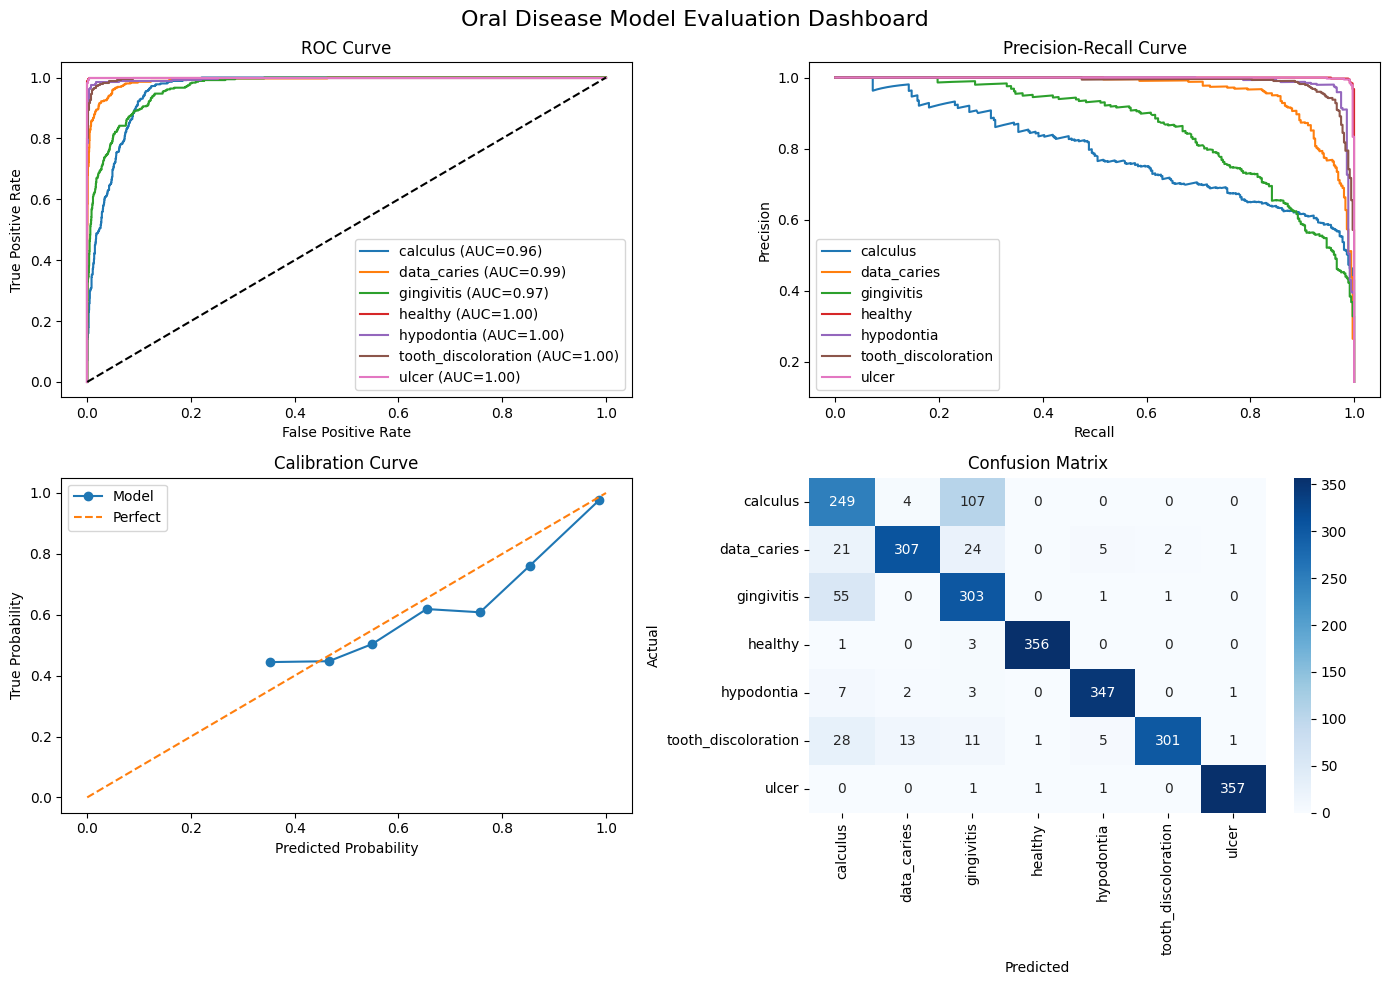

In [22]:
model_evaluation_dashboard(
    y_true_o,
    y_pred_o,
    y_prob_o,
    oral_classes,
    model_name="Oral Disease Model"
)